In [15]:
from nrem_sc.constants import PROCESSED_DATA_PATH, INTERIM_DATA_PATH

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import pynapple as nap

from matplotlib import pyplot as plt
from cmap import Colormap

# ── Global style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       320,
    "font.family":       "arial",
    "font.size":         26,
    "axes.titlesize":    26,
    "axes.labelsize":    26,
    "xtick.labelsize":   22,
    "ytick.labelsize":   22,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         False,
    "legend.frameon":    False,
    "figure.constrained_layout.use": True,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
})

# ── Cyclic colormap ────────────────────────────────────────────────────────
cmap = Colormap("cmocean:phase")
if "cmocean:phase" not in mpl.colormaps:
    mpl.colormaps.register(cmap.to_mpl())


# ── Helpers ────────────────────────────────────────────────────────────────
set2 = Colormap('colorbrewer:Set2').color_stops
STATE_STYLES = {
    "stationary":  dict(color=set2[0].color.hex, label="Stationary"),
    "fragmented":  dict(color=set2[1].color.hex, label="Fragmented"),
    "continuous":  dict(color=set2[2].color.hex, label="Continuous"),
    }

In [16]:
unit_id = "116b"

# Data
sleep_states = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sleep.npz")
hd_spikes    = nap.load_file(PROCESSED_DATA_PATH / unit_id / "hd_spikes_filtered.npz")
hd_angle     = np.deg2rad(nap.load_file(PROCESSED_DATA_PATH / unit_id / "angle_openfield.npz"))

from scipy.ndimage import gaussian_filter1d
tcs = nap.compute_tuning_curves(
    data=hd_spikes.restrict(hd_angle.time_support), features=hd_angle, bins=60,
    epochs=hd_angle.time_support, range=(0.0, 2*np.pi), feature_names=['head_direction']
    )

tcs.values = gaussian_filter1d(tcs.values, sigma=3, axis=1, mode="wrap")
pref_ang = tcs.idxmax(dim="head_direction")

norm_tcs = (tcs - tcs.min(dim='head_direction')) / (tcs.max(dim='head_direction') - tcs.min(dim='head_direction'))

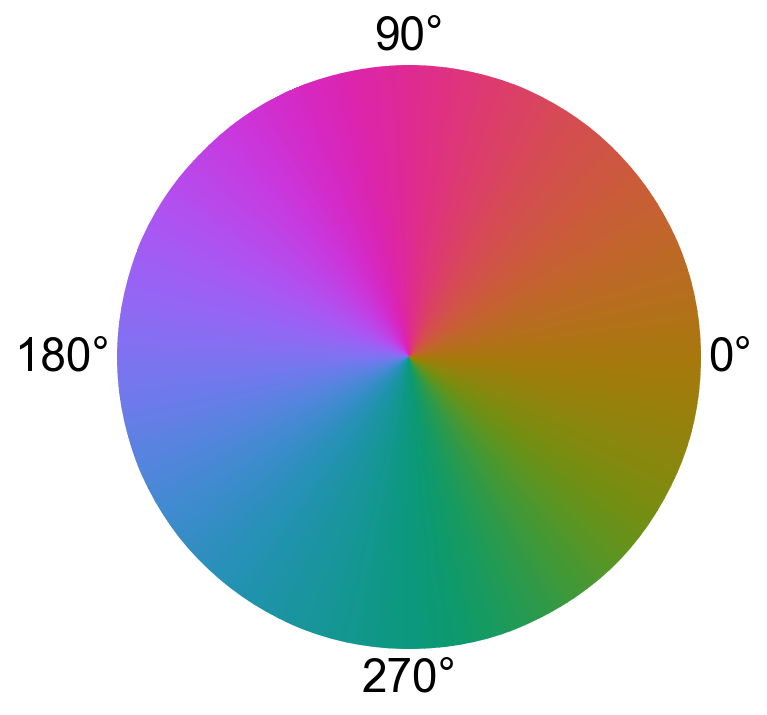

In [17]:
fig_disc, ax_disc = plt.subplots(figsize=(5, 5), subplot_kw={"projection": "polar"})

theta = np.linspace(0, 2 * np.pi, 256)
radii = np.linspace(0.5, 1, 2)
T, R = np.meshgrid(theta, radii)

ax_disc.pcolormesh(T, R, T, cmap="cmocean:phase", shading="auto")
ax_disc.set_yticks([])
ax_disc.set_xticks([])
ax_disc.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2],
                   labels=["0°", "90°", "180°    ", "270°"])
ax_disc.spines["polar"].set_visible(False)
ax_disc.spines
ax_disc.grid(False)
plt.show()
# fig_disc.savefig(INTERIM_DATA_PATH / unit_id / "sweep_disc_colormap.pdf", format="pdf", transparent=True)

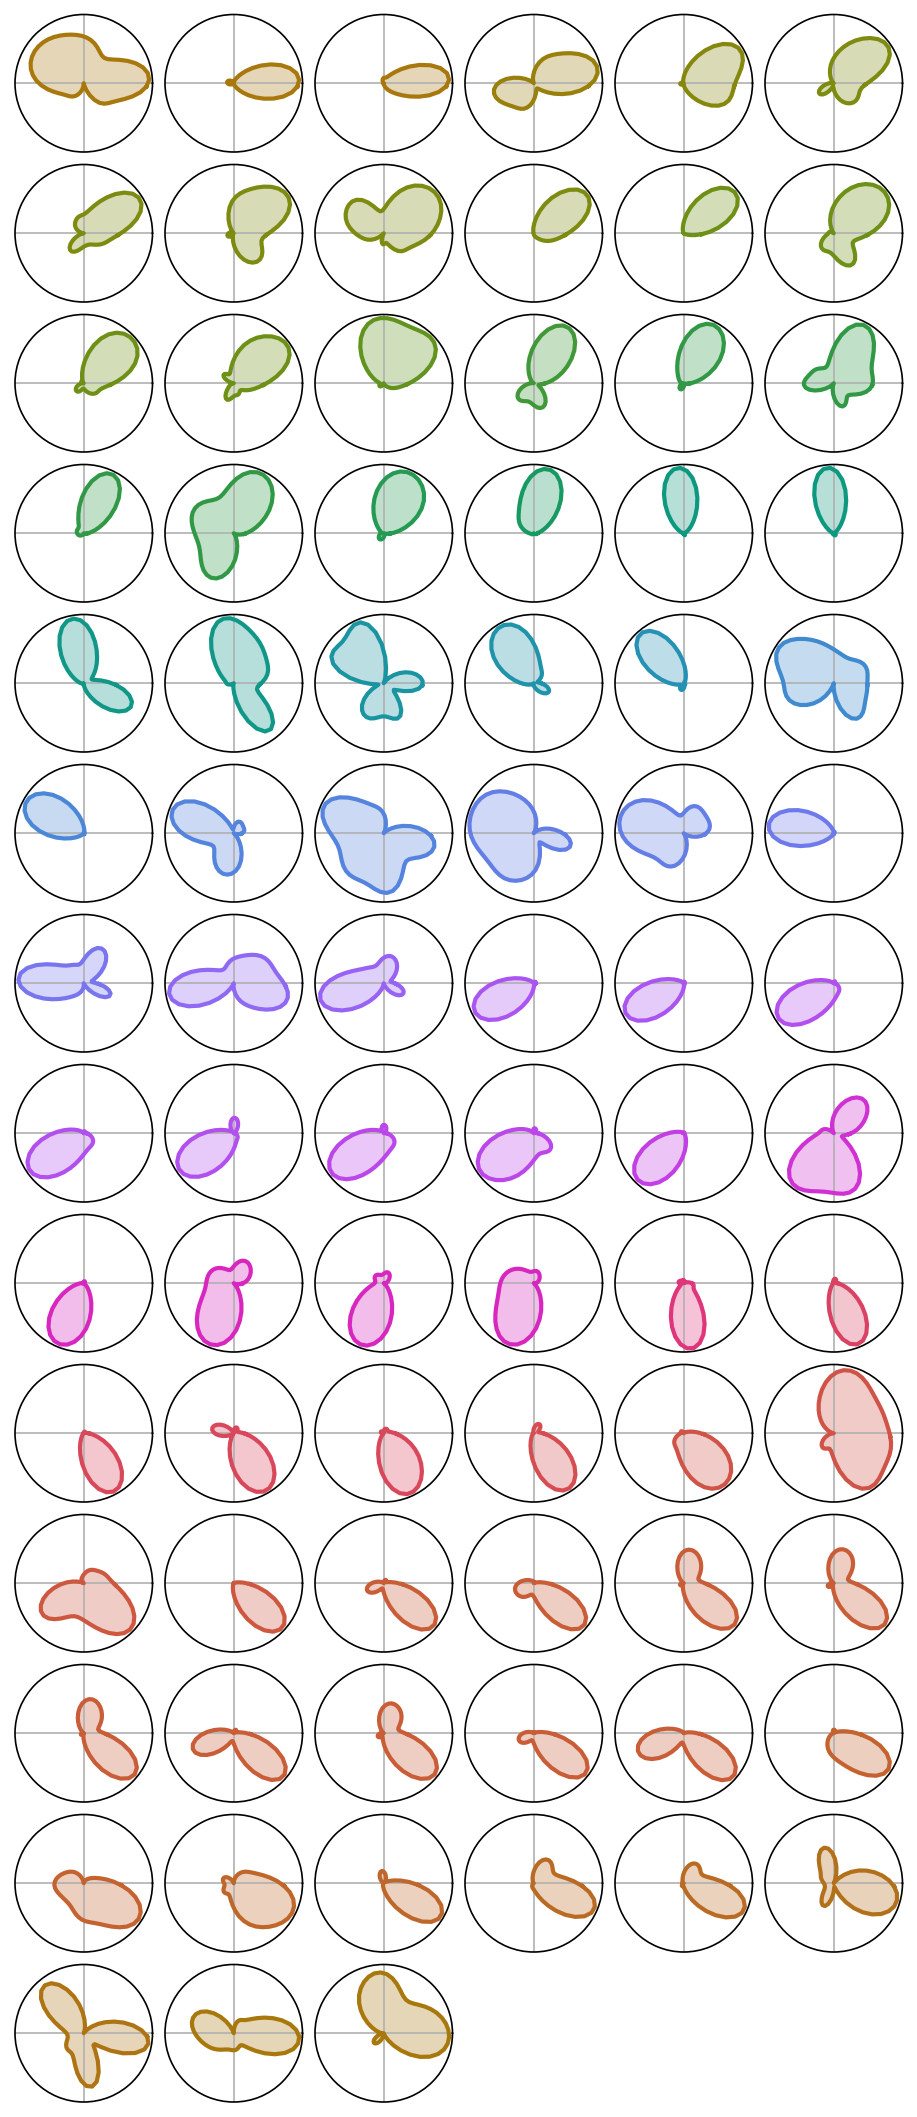

In [34]:
norm = plt.Normalize()
colors = cmap(norm([i / (2 * np.pi) for i in pref_ang.values]))
sorted_units = pref_ang.to_numpy().argsort()[::-1]

n_units = len(pref_ang)
ncols = min(n_units, 6)
nrows = int(np.ceil(n_units / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(1 * ncols, 1 * nrows),
                         subplot_kw={'projection': 'polar'})
axes = np.atleast_2d(axes)

for ax in axes.flat:
    ax.set_visible(False)

angles = tcs['head_direction'].values
angles_closed = np.append(angles, angles[0] + 2 * np.pi)

for j, uid in enumerate(sorted_units):
    c = colors[uid]
    ax = axes.flat[j]
    ax.set_visible(True)
    ax.set_theta_direction(-1)
    tc_closed = np.append(norm_tcs[uid, :].values, norm_tcs[uid, :].values[0])
    ax.plot(angles_closed, tc_closed, color=c, linewidth=2)
    ax.fill(angles_closed, tc_closed, color=c, alpha=0.3)
    ax.set_yticks([])
    ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
    ax.set_xticklabels([])
    ax.set_title('')

save_dir = INTERIM_DATA_PATH / unit_id / 'figures'
save_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(save_dir / 'tuning_curves.pdf', format='pdf', dpi=1200)